# Reduced EDA Workbook

This notebook reproduces the reduced-tier feature-engineering plots that are currently written to `notebooks/eda_plots/reduced_feature_engineering`.

It is designed for the mentor-directed reduced-only workflow:
- build the reduced pre-model frame from processed training data
- generate the reduced EDA plots
- inspect the summary JSON
- preview all generated figures inside the notebook

In [24]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/91816/OneDrive/Desktop/Barclays123/AI_CreditScoring')

In [25]:
import pandas as pd
from IPython.display import Image, Markdown, display

from src.plot_feature_engineering_eda import generate_feature_engineering_eda
from src.feature_engineering import _build_pre_model_frame, ENGINEERED_APP_FEATURE_COLS

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'eda_plots' / 'reduced_feature_engineering'
SUMMARY_PATH = OUTPUT_DIR / 'reduced_feature_engineering_eda_summary.json'

## 1. Load Reduced Training Frame

In [26]:
train_df = pd.read_pickle(PROCESSED_DIR / 'train.pkl')
reduced_pre_model = _build_pre_model_frame(
    train_df,
    'REDUCED',
    raw_dir=None,
    allow_flattened_full_input=False,
)
reduced_pre_model['TARGET'] = train_df['TARGET'].to_numpy()

print('Train rows:', len(train_df))
print('Reduced pre-model feature count:', len([c for c in reduced_pre_model.columns if c != 'TARGET']))
print('Engineered reduced features present:', len([c for c in ENGINEERED_APP_FEATURE_COLS if c in reduced_pre_model.columns]))

Train rows: 184506
Reduced pre-model feature count: 56
Engineered reduced features present: 24


## 2. Generate Reduced EDA Plots

In [27]:
generate_feature_engineering_eda(
    processed_dir=str(PROCESSED_DIR),
    raw_dir=str(PROJECT_ROOT / 'data' / 'raw'),
    output_dir=str(OUTPUT_DIR),
)

print('Saved plots to:', OUTPUT_DIR)

Saved plots to: C:\Users\91816\OneDrive\Desktop\Barclays123\AI_CreditScoring\notebooks\eda_plots\reduced_feature_engineering


## 3. Read Summary JSON

In [28]:
with open(SUMMARY_PATH, 'r', encoding='utf-8') as f:
    summary = json.load(f)

summary.keys()

dict_keys(['processed_dir', 'output_dir', 'input_application_columns', 'reduced_pre_model_feature_count', 'engineered_feature_count', 'engineered_features_present', 'feature_family_counts', 'top_features_by_univariate_auc', 'top_features_by_target_gap', 'top_missing_features', 'engineered_feature_focus', 'categorical_default_rate_highlights'])

In [29]:
display(Markdown('### Headline Metrics'))
print('Reduced pre-model feature count:', summary['reduced_pre_model_feature_count'])
print('Engineered feature count:', summary['engineered_feature_count'])
print('Top engineered focus features:', summary['engineered_feature_focus'])

### Headline Metrics

Reduced pre-model feature count: 56
Engineered feature count: 24
Top engineered focus features: ['EXT_123_PRODUCT', 'EXT_13_PRODUCT', 'EXT_SOURCE_MEAN', 'EXT_23_PRODUCT', 'EXT_12_PRODUCT', 'EXT_MIN']


In [30]:
display(Markdown('### Top Features By Univariate ROC-AUC'))
pd.DataFrame(summary['top_features_by_univariate_auc']).head(10)

### Top Features By Univariate ROC-AUC

,feature,family,missing_rate,univariate_auc,mean_no_default,mean_default,abs_target_gap
0,EXT_123_PRODUCT,ENGINEERED_TRUST,0.650445,0.738914,0.158911,0.079058,0.079853
1,EXT_13_PRODUCT,ENGINEERED_TRUST,0.649957,0.719463,0.285051,0.169819,0.115232
2,EXT_SOURCE_MEAN,ENGINEERED_TRUST,0.000444,0.713813,0.531870,0.413766,0.118104
3,EXT_23_PRODUCT,ENGINEERED_TRUST,0.178905,0.709695,0.288465,0.180070,0.108394
4,EXT_12_PRODUCT,ENGINEERED_TRUST,0.587211,0.698136,0.294265,0.186679,0.107586
5,EXT_MIN,ENGINEERED_TRUST,0.000444,0.688972,0.422316,0.296010,0.126305
6,EXT_MAX,ENGINEERED_TRUST,0.000444,0.679726,0.637791,0.531377,0.106413
7,EXT_SOURCE_3,RAW_NUMERIC,0.177366,0.671340,0.538592,0.414336,0.124256
8,EXT_SOURCE_1,RAW_NUMERIC,0.586588,0.664939,0.532207,0.408742,0.123465
9,EXT_SOURCE_2,RAW_NUMERIC,0.002119,0.650482,0.529477,0.421561,0.107916


In [31]:
display(Markdown('### Top Features By Target Gap'))
pd.DataFrame(summary['top_features_by_target_gap']).head(10)

### Top Features By Target Gap

,feature,family,missing_rate,univariate_auc,mean_no_default,mean_default,abs_target_gap
0,AMT_GOODS_PRICE,RAW_NUMERIC,0.000791,0.521377,544180.709932,504089.201196,40091.508736
1,AMT_CREDIT,RAW_NUMERIC,0.000000,0.506917,603672.076370,573856.673572,29815.402798
2,AMT_INCOME_TOTAL_CAPPED,RAW_NUMERIC,0.000000,0.510128,164764.421282,159680.539133,5083.882149
3,DAYS_BIRTH,RAW_NUMERIC,0.000000,0.579987,-17027.809301,-15823.643743,1204.165557
4,DAYS_EMPLOYED,RAW_NUMERIC,0.258062,0.582010,-2624.286938,-1981.994270,642.292668
5,DAYS_REGISTRATION,RAW_NUMERIC,0.000000,0.539702,-5300.959772,-4773.718563,527.241209
6,AMT_ANNUITY,RAW_NUMERIC,0.000043,0.507950,26985.230083,26641.653814,343.576270
7,DAYS_LAST_PHONE_CHANGE,RAW_NUMERIC,0.000000,0.546409,-1029.576921,-888.404197,141.172725
8,DAYS_ID_PUBLISH,RAW_NUMERIC,0.000000,0.538855,-4081.216806,-3991.911472,89.305334
9,AGE_YEARS,ENGINEERED_AFFORDABILITY,0.000000,0.579987,46.651532,43.352449,3.299084


In [32]:
display(Markdown('### Feature Family Counts'))
pd.DataFrame(summary['feature_family_counts'])

### Feature Family Counts

,family,feature_count
0,Raw Numeric,25
1,Engineered Trust,13
2,Categorical Context,7
3,Engineered Affordability,6
4,Engineered Stability,3
5,Engineered Behavioral,2


## 4. Preview Generated Plots

### reduced_feature_family_counts.png

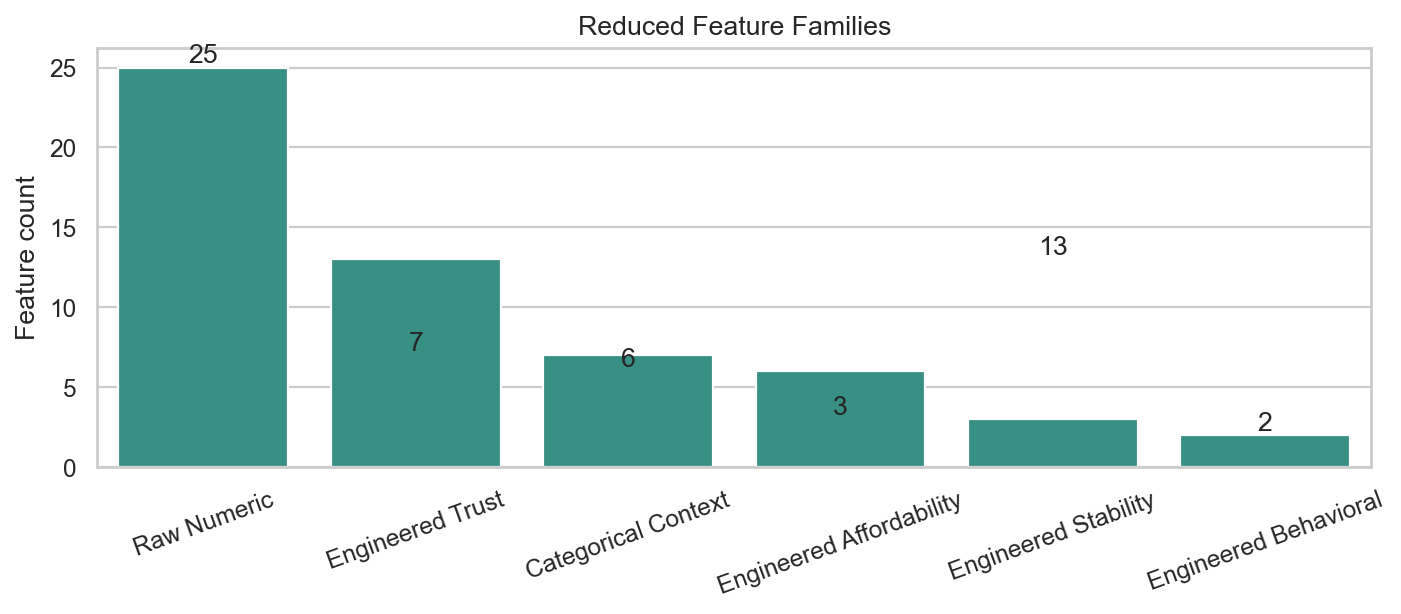

### reduced_missingness_top20.png

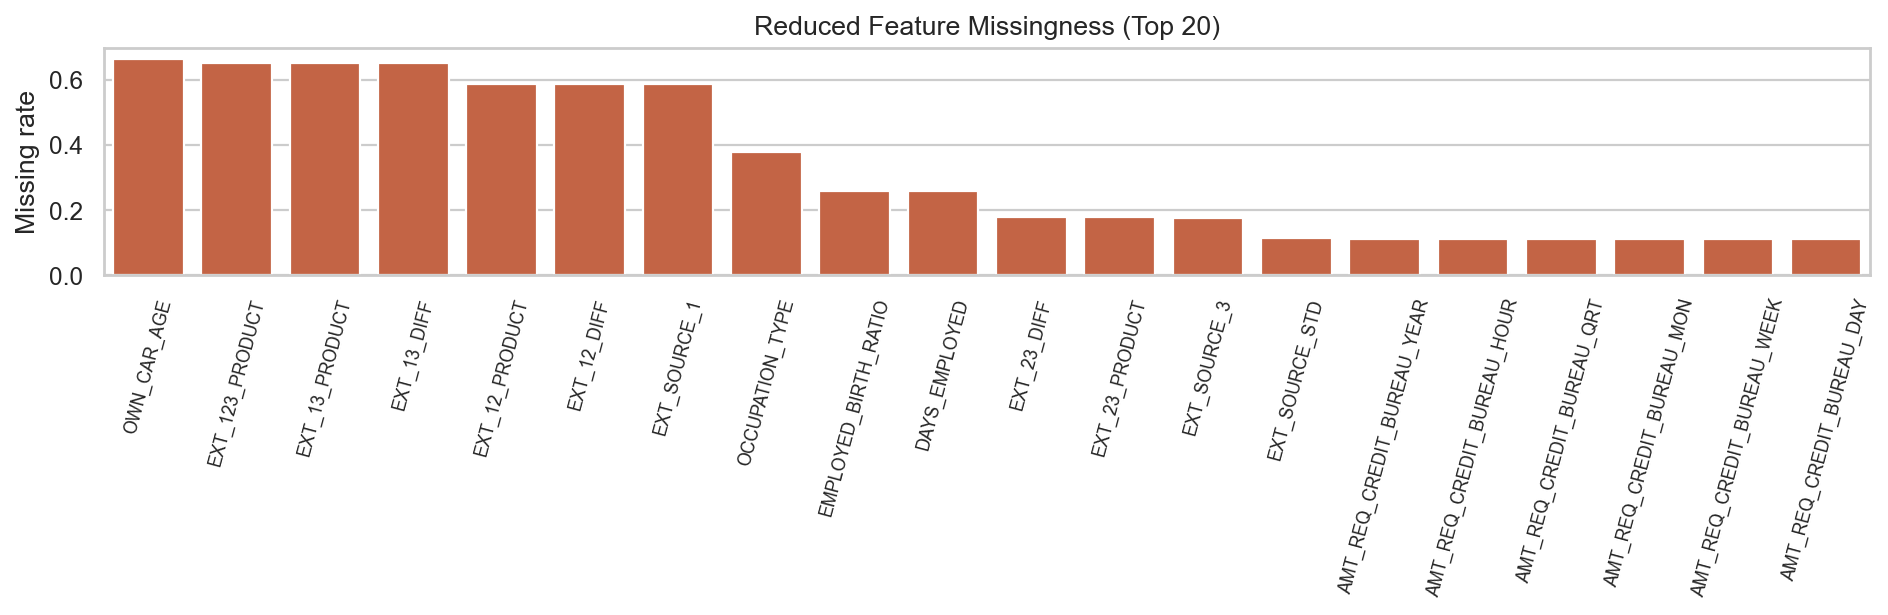

### reduced_univariate_auc_top15.png

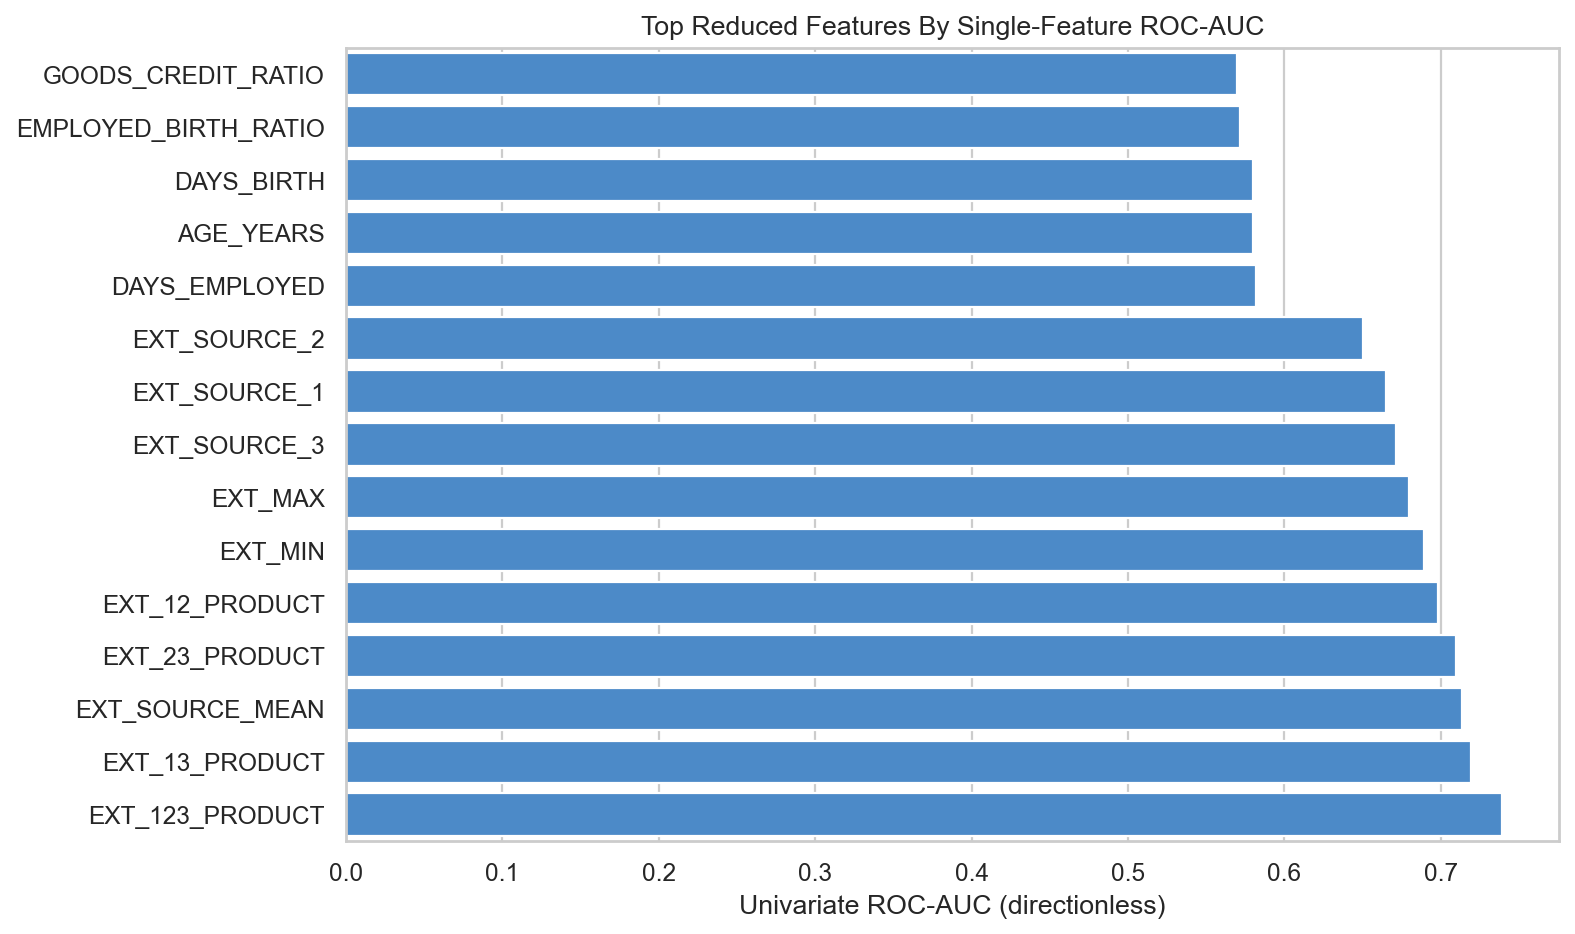

### reduced_target_gap_top15.png

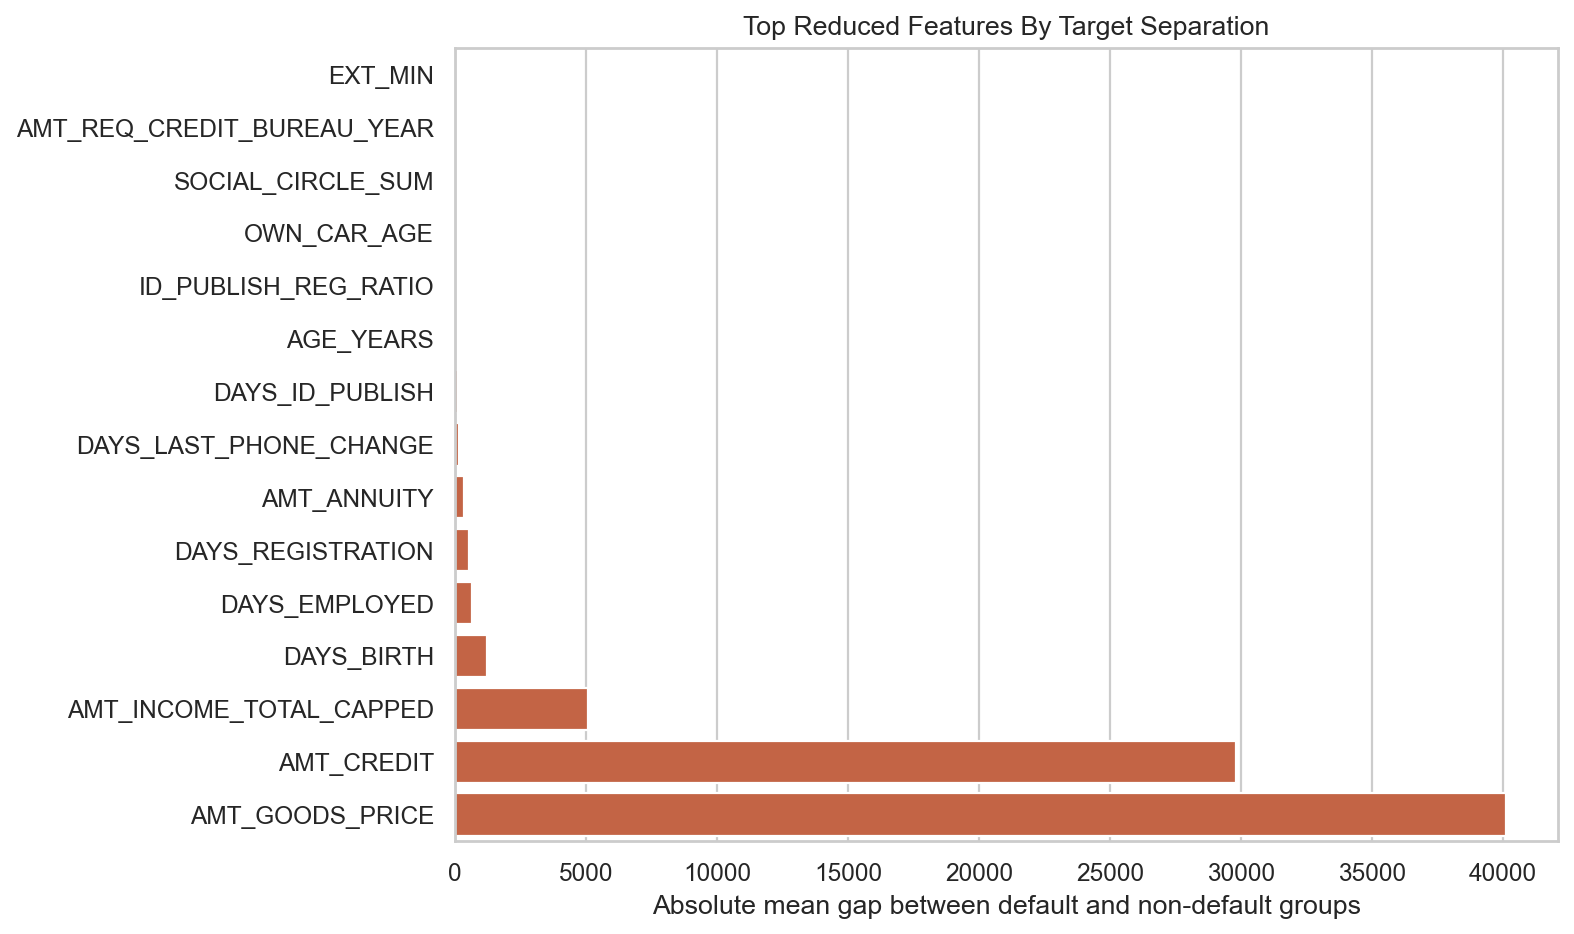

### reduced_feature_correlation_heatmap.png

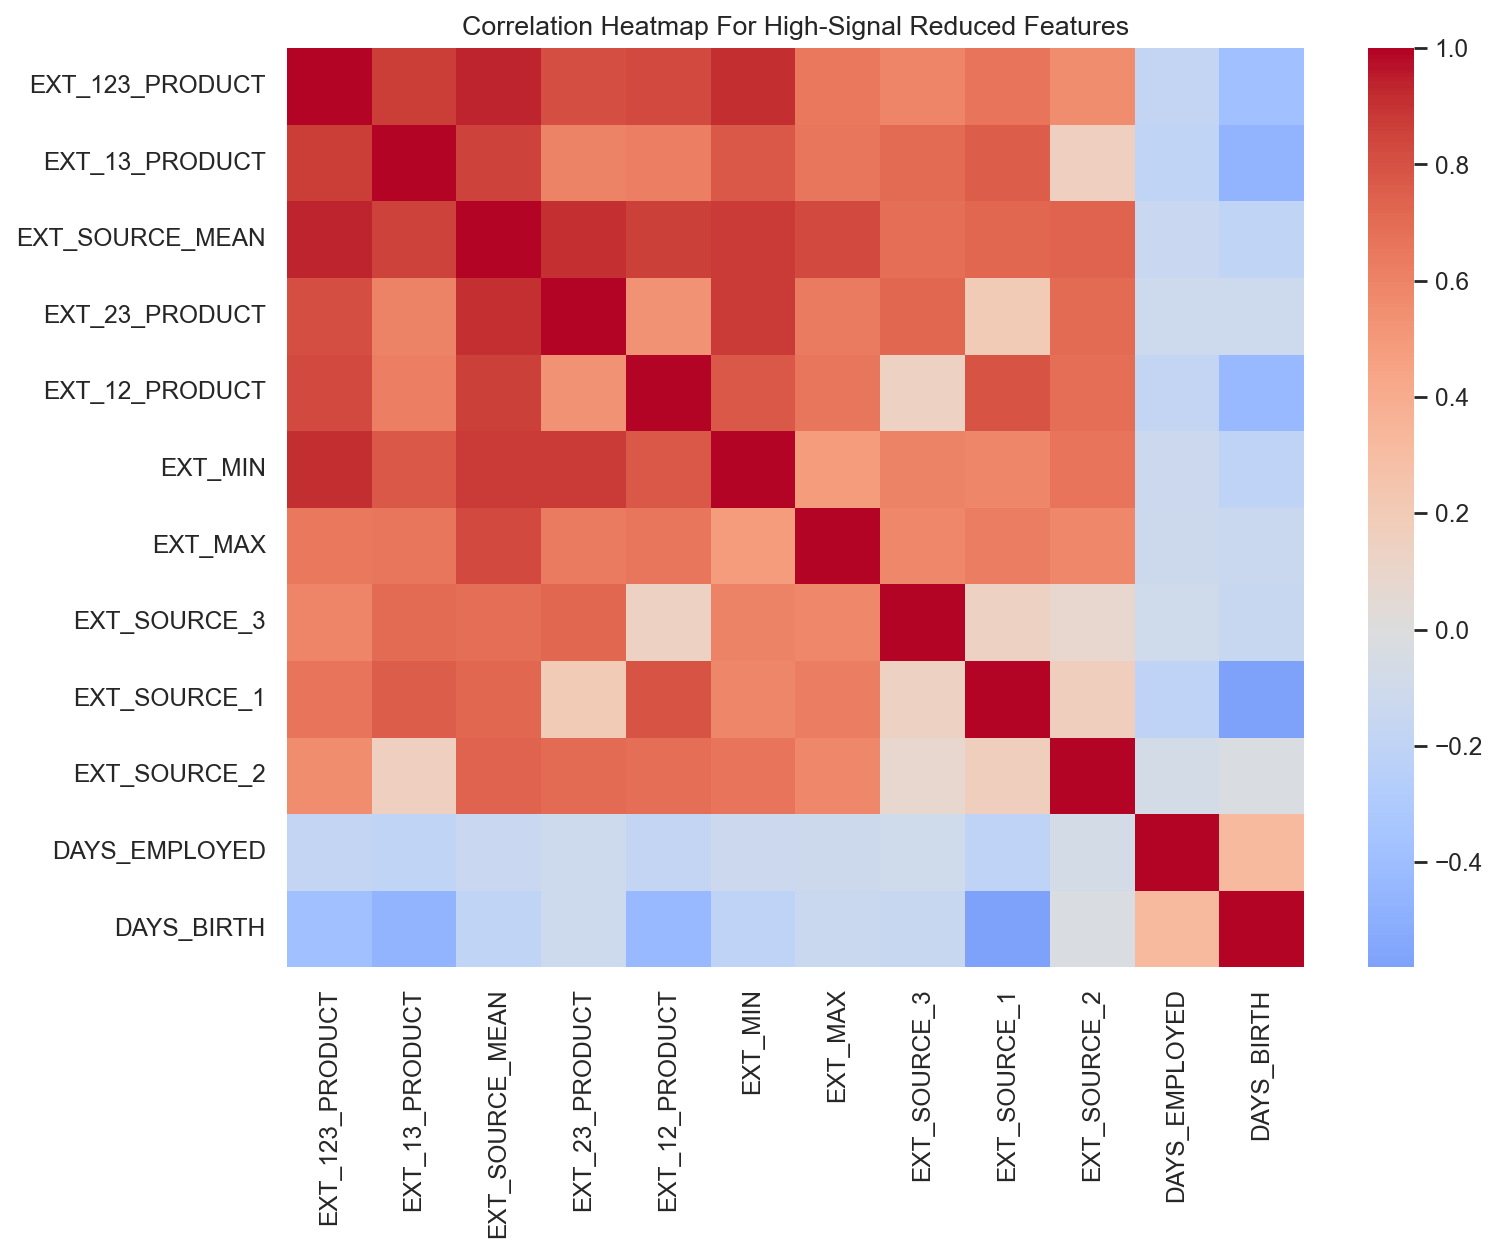

### reduced_engineered_feature_distributions.png

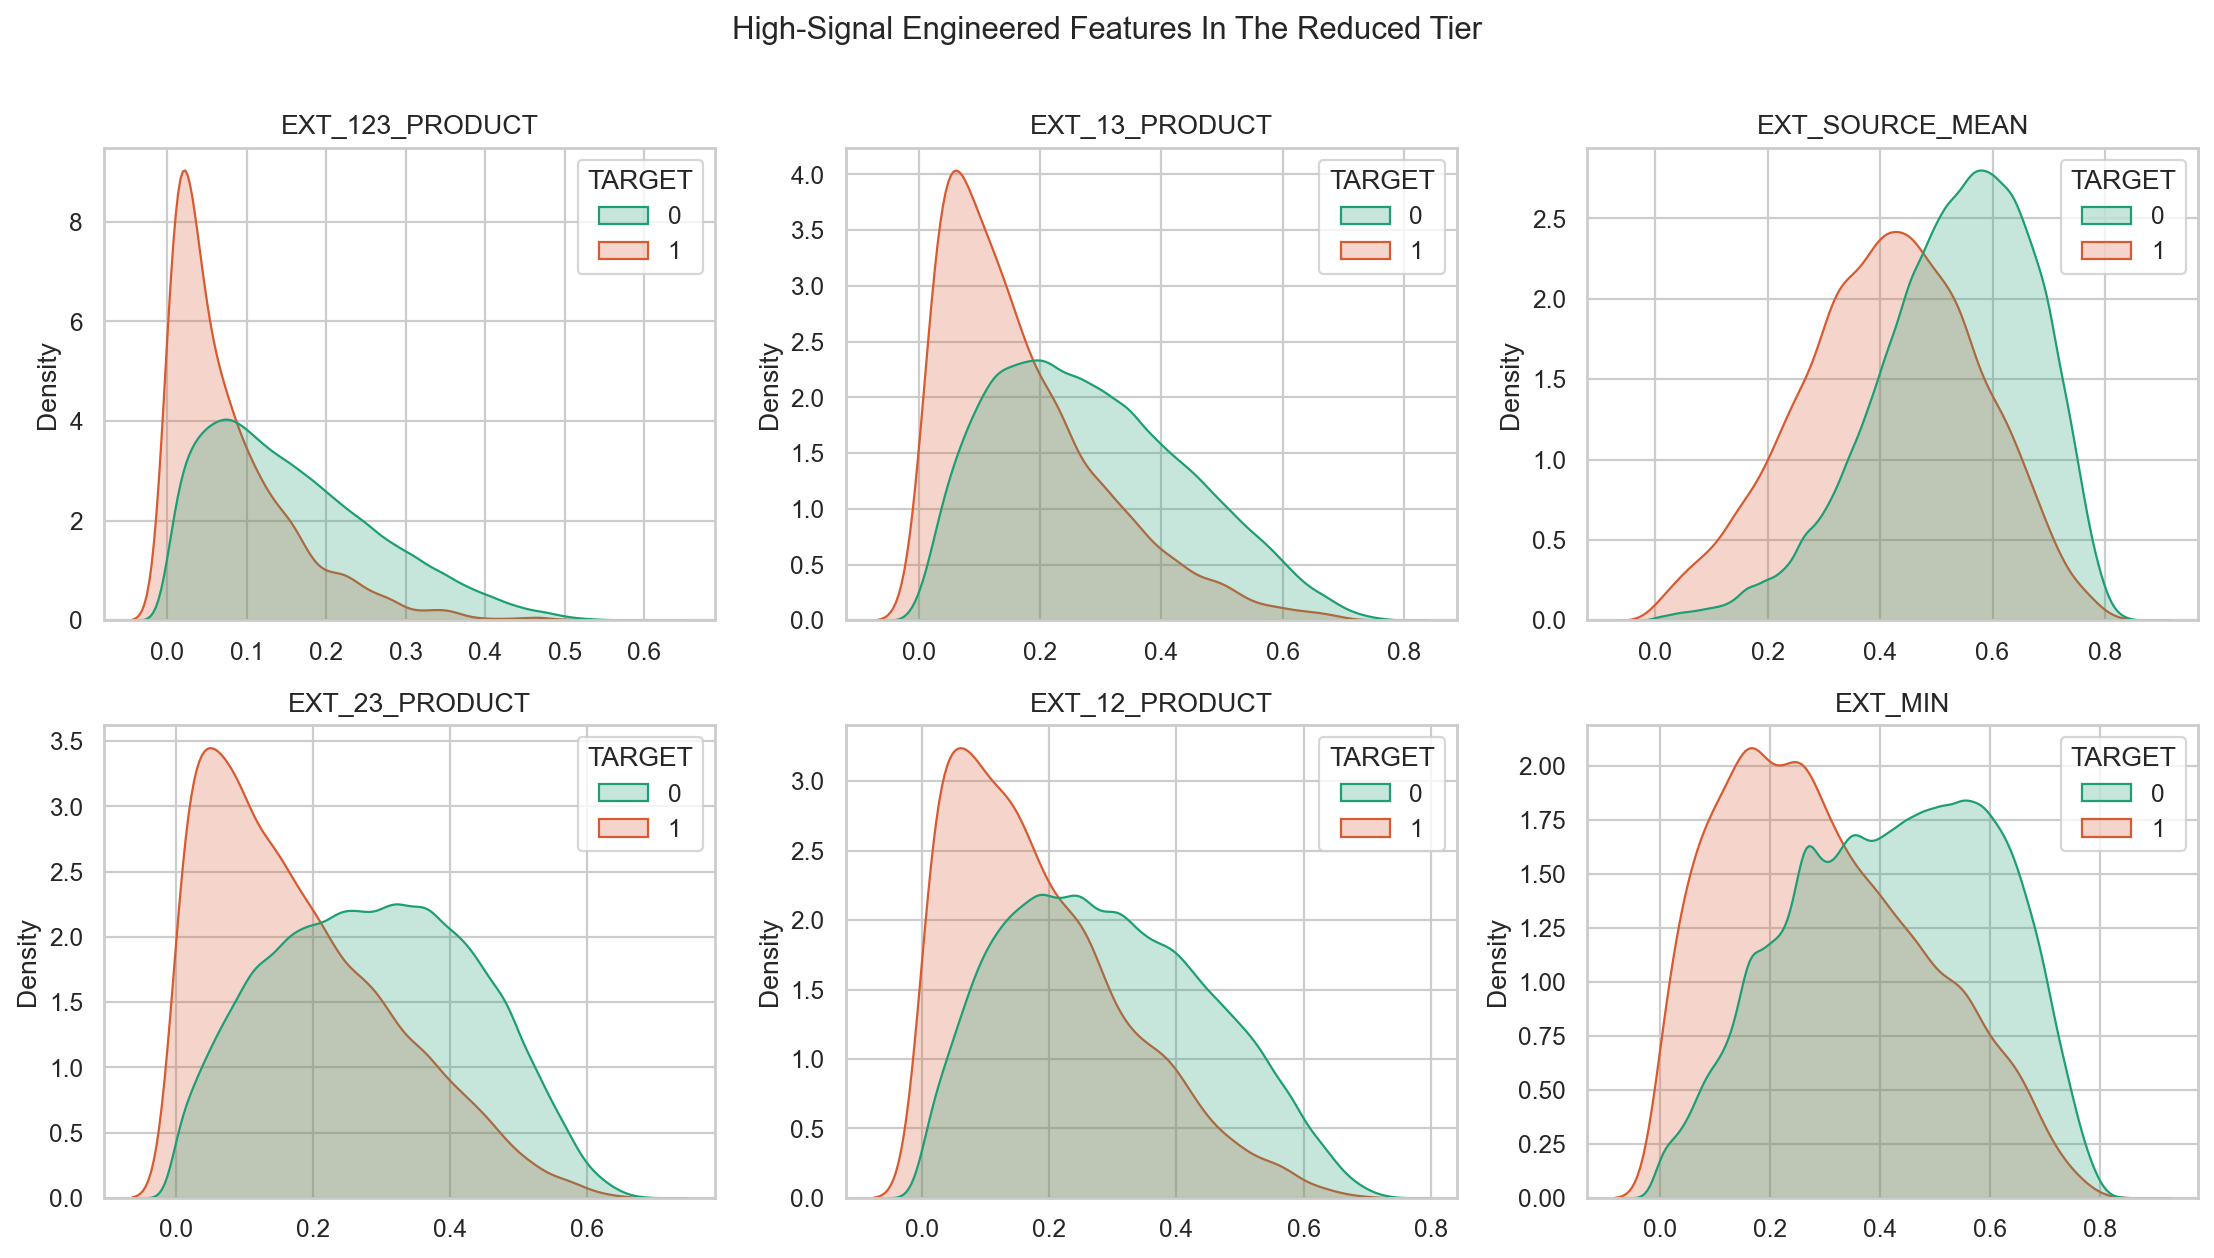

### reduced_categorical_default_rate_name_contract_type.png

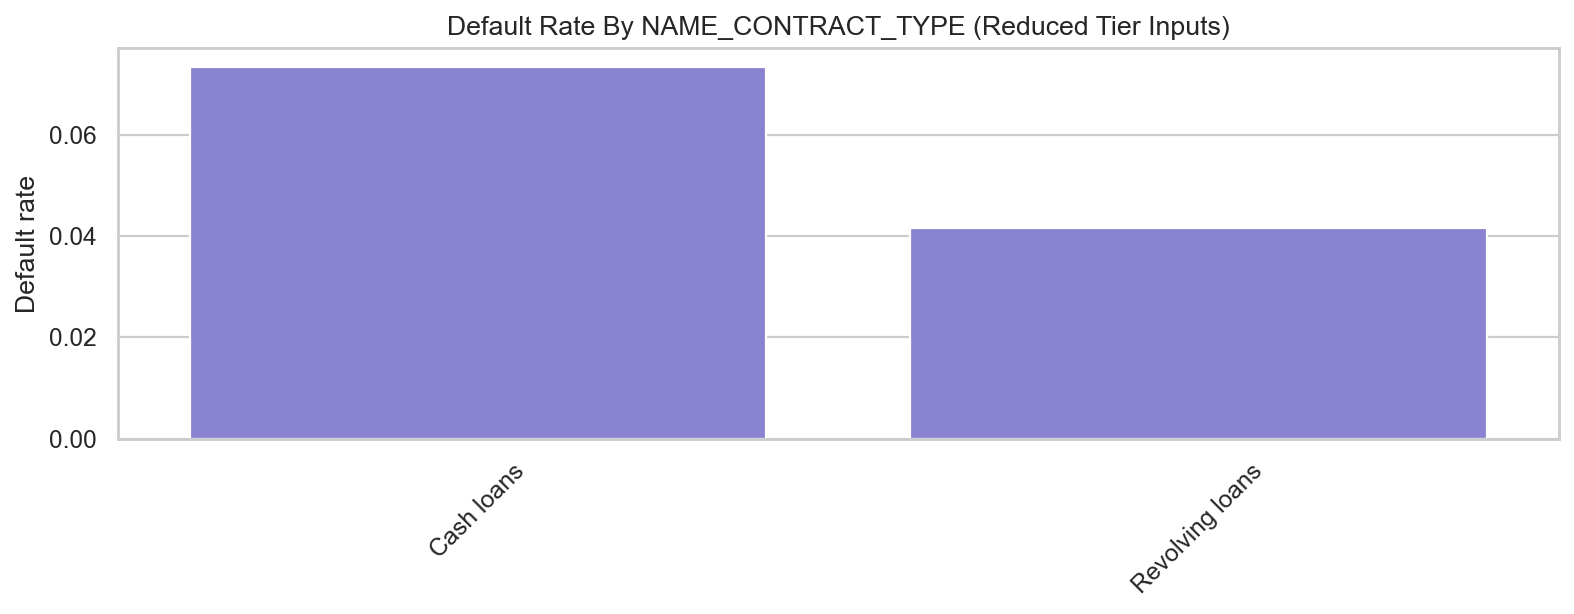

### reduced_categorical_default_rate_name_education_type.png

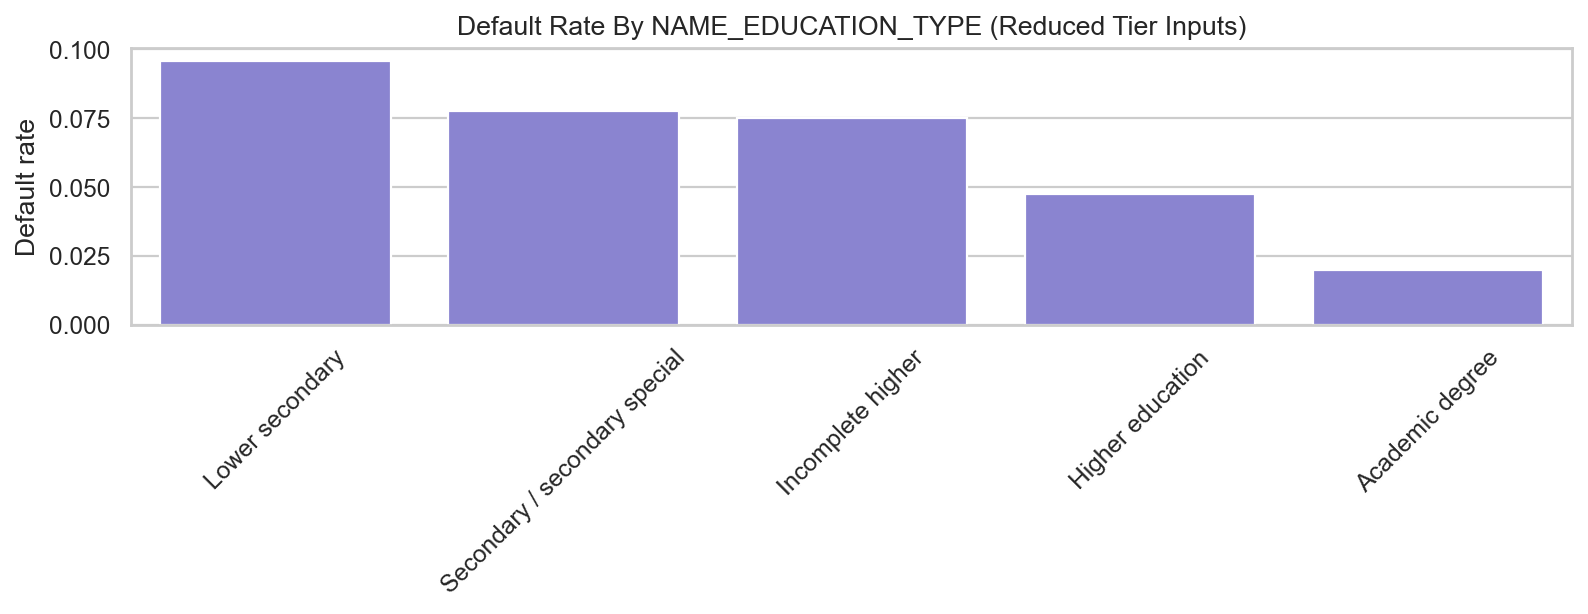

### reduced_categorical_default_rate_name_family_status.png

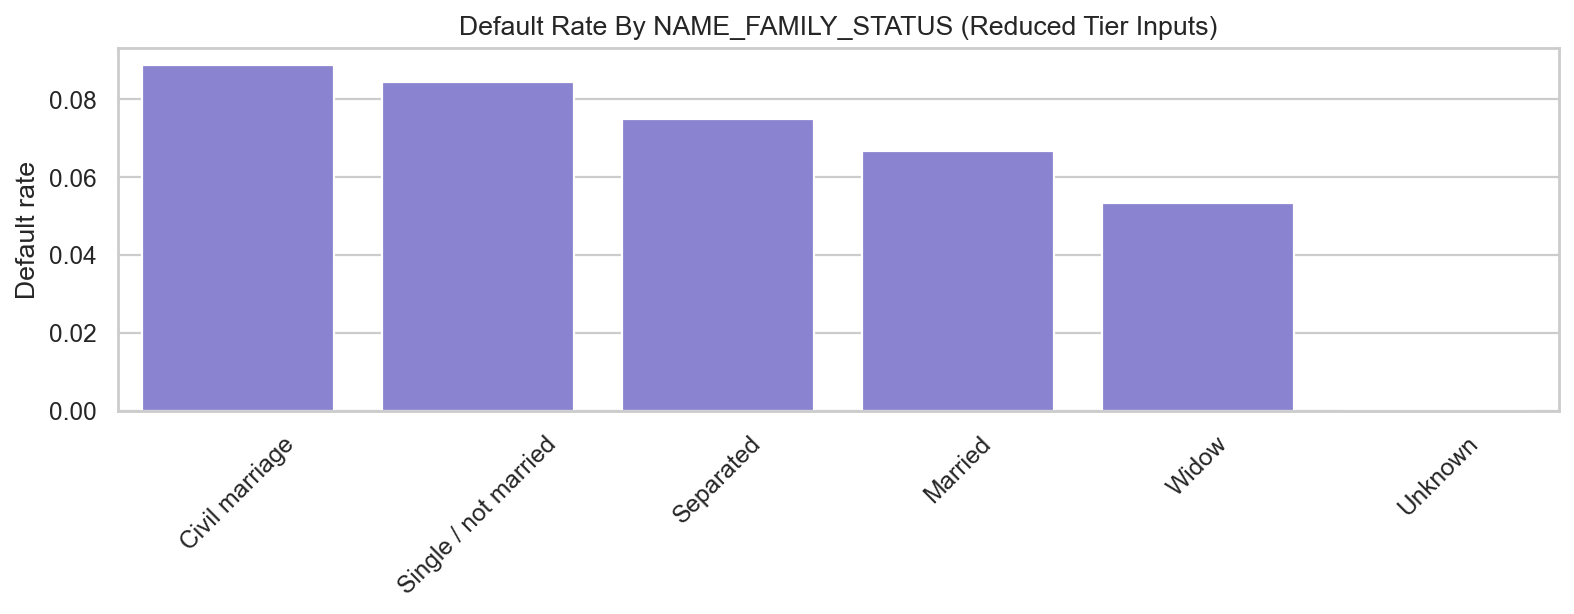

### reduced_categorical_default_rate_name_type_suite.png

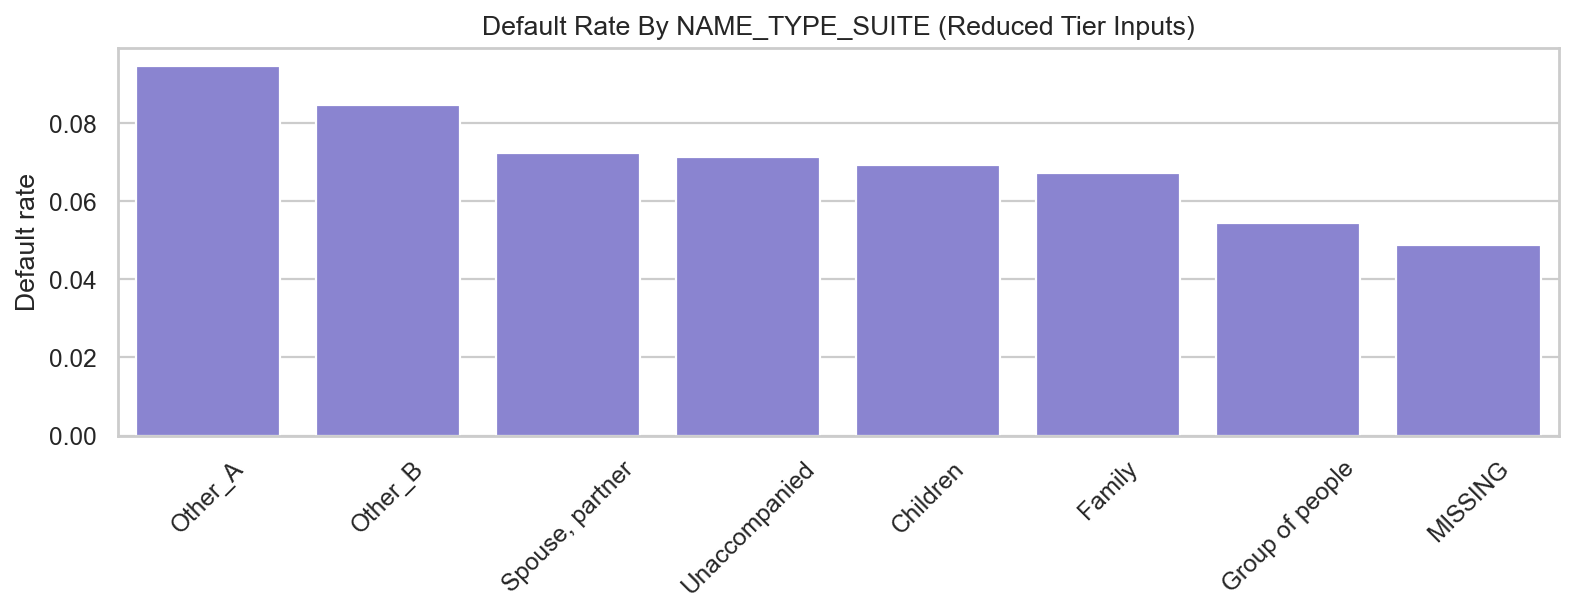

### reduced_categorical_default_rate_occupation_type.png

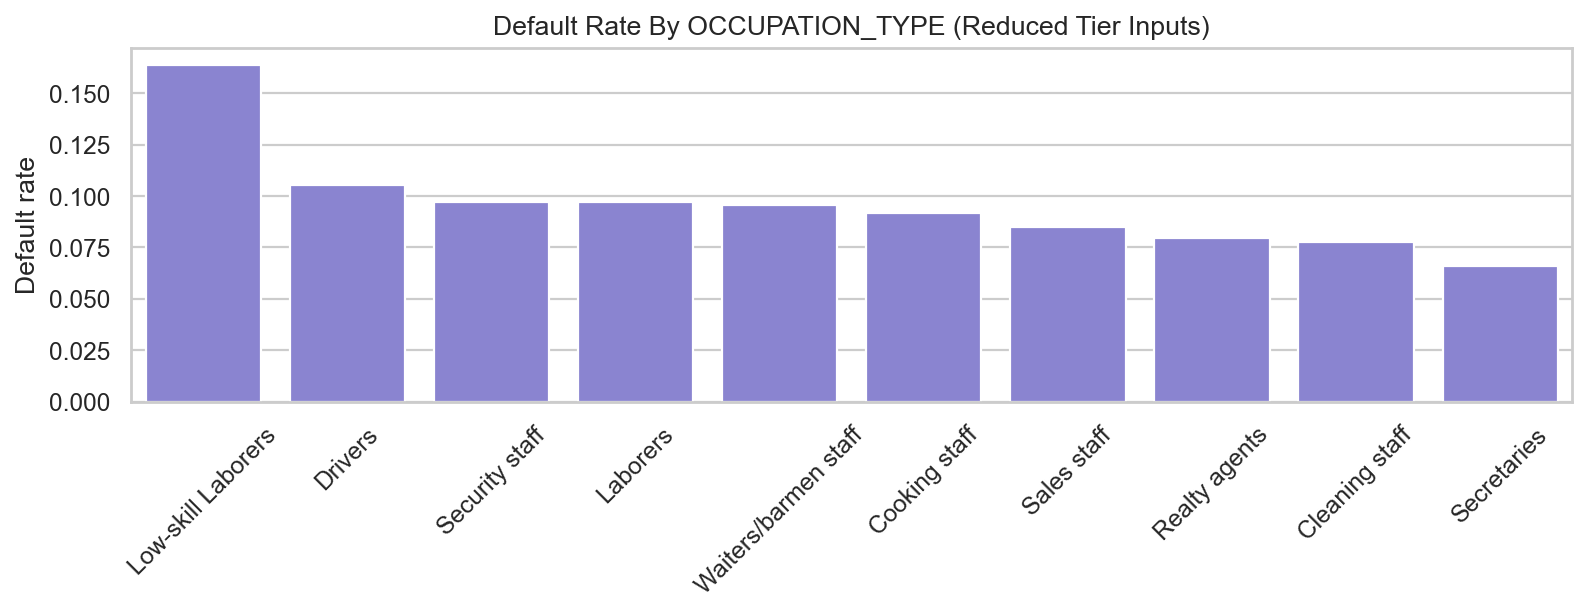

### reduced_categorical_default_rate_organization_type.png

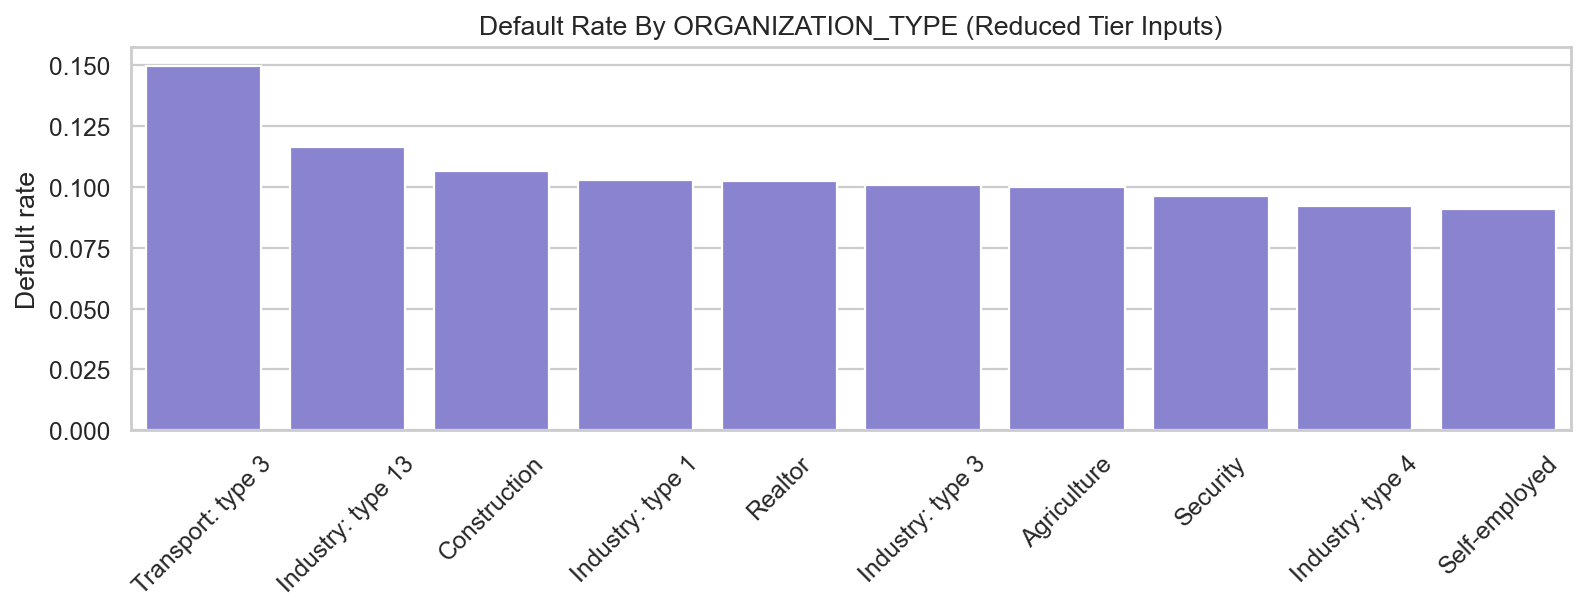

### reduced_categorical_default_rate_weekday_appr_process_start.png

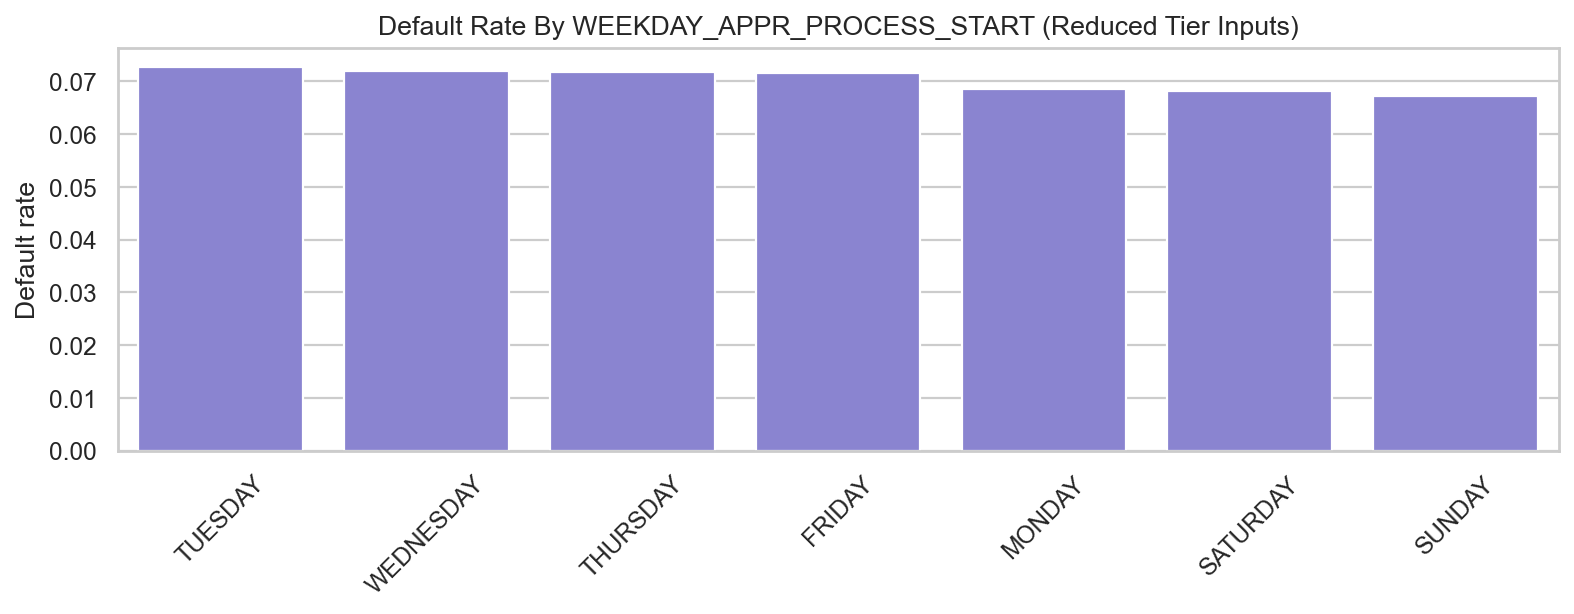

In [33]:
plot_files = [
    'reduced_feature_family_counts.png',
    'reduced_missingness_top20.png',
    'reduced_univariate_auc_top15.png',
    'reduced_target_gap_top15.png',
    'reduced_feature_correlation_heatmap.png',
    'reduced_engineered_feature_distributions.png',
    'reduced_categorical_default_rate_name_contract_type.png',
    'reduced_categorical_default_rate_name_education_type.png',
    'reduced_categorical_default_rate_name_family_status.png',
    'reduced_categorical_default_rate_name_type_suite.png',
    'reduced_categorical_default_rate_occupation_type.png',
    'reduced_categorical_default_rate_organization_type.png',
    'reduced_categorical_default_rate_weekday_appr_process_start.png',
]

for plot_name in plot_files:
    plot_path = OUTPUT_DIR / plot_name
    if plot_path.exists():
        display(Markdown(f'### {plot_name}'))
        display(Image(filename=str(plot_path)))
    else:
        print('Missing plot:', plot_path)

## 5. Optional: Open The Output Folder Listing

In [ ]:
sorted([p.name for p in OUTPUT_DIR.glob('*')])